# Market Basket Segmentation Using K-Means Clustering

**Objective:** Analyze customer purchase data from a retail company and group customers into
distinct segments based on their spending behavior and purchase channels, using the
K-Means Clustering algorithm.

**Workflow:**
1. Dataset loading & preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature engineering & selection
4. Feature scaling
5. Finding the optimal number of clusters (Elbow Method + Silhouette Score)
6. Applying K-Means Clustering
7. Visualizing the clusters (PCA)
8. Interpreting the purchasing patterns of each customer segment


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)


## 2. Load the Dataset

The dataset (`customer_segmentation.csv`) is the *Customer Personality Analysis* dataset,
containing demographic information, purchase amounts by product category, purchase channels,
and marketing campaign responses for 2,240 customers.

In [2]:
df = pd.read_csv("customer_segmentation.csv")
print("Shape:", df.shape)
df.head()


Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [4]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


## 3. Dataset Preprocessing

### 3.1 Missing values
Only the `Income` column has missing values (24 rows, ~1% of the data). We drop these rows
rather than impute, since the loss is small and clustering results can be sensitive to imputed values.

In [5]:
df.isnull().sum()[df.isnull().sum() > 0]

Income    24
dtype: int64

In [6]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print("Shape after dropping missing Income values:", df.shape)


Shape after dropping missing Income values: (2216, 29)


### 3.2 Duplicates

In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### 3.3 Categorical clean-up

`Marital_Status` contains a few noisy/inconsistent categories (`Alone`, `Absurd`, `YOLO`)
which are artifacts of manual data entry. We consolidate them into sensible groups.

In [8]:
df["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [9]:
df["Marital_Status"] = df["Marital_Status"].replace({
    "Alone": "Single",
    "Absurd": "Single",
    "YOLO": "Single"
})
df["Marital_Status"].value_counts()


Marital_Status
Married     857
Together    573
Single      478
Divorced    232
Widow        76
Name: count, dtype: int64

### 3.4 Outlier removal

`Year_Birth` contains a few implausible values (e.g. birth year 1893 -> age 130+), and
`Income` has an extreme outlier (666,666). These are removed so they don't distort scaling
and cluster centers.

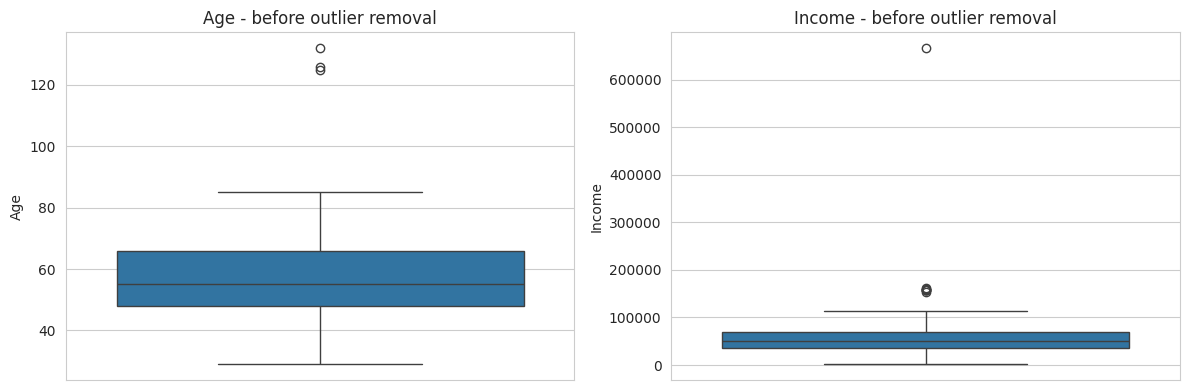

In [10]:
df["Age"] = 2025 - df["Year_Birth"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df["Age"], ax=axes[0])
axes[0].set_title("Age - before outlier removal")
sns.boxplot(y=df["Income"], ax=axes[1])
axes[1].set_title("Income - before outlier removal")
plt.tight_layout()
plt.show()


In [11]:
df = df[df["Age"] <= 90]
df = df[df["Income"] <= 200000]
df.reset_index(drop=True, inplace=True)
print("Shape after outlier removal:", df.shape)


Shape after outlier removal: (2212, 30)


### 3.5 Date parsing

In [12]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
df["Dt_Customer"].describe()


count                          2212
mean     2013-07-10 06:51:25.714285
min             2012-07-30 00:00:00
25%             2013-01-16 00:00:00
50%             2013-07-08 00:00:00
75%             2013-12-31 00:00:00
max             2014-06-29 00:00:00
Name: Dt_Customer, dtype: object

## 4. Feature Engineering

We derive several customer-level features that summarize spending behavior, household
composition, and tenure, which will be useful both for EDA and for clustering.

In [13]:
# Total children in the household
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

# Total amount spent across all product categories (the "basket size")
spend_cols = ["MntWines", "MntFruits", "MntMeatProducts",
              "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
df["Total_Spending"] = df[spend_cols].sum(axis=1)

# Total number of purchases across all channels
purchase_cols = ["NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
df["Total_Purchases"] = df[purchase_cols].sum(axis=1)

# How long (in days) the customer has been enrolled, relative to the most recent enrollment date
df["Customer_Since_Days"] = (df["Dt_Customer"].max() - df["Dt_Customer"]).dt.days

# Whether the customer accepted ANY marketing campaign (1-5th campaign or the last Response)
campaign_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]
df["AcceptedAny"] = (df[campaign_cols].sum(axis=1) > 0).astype(int)

df[["Age", "Total_Children", "Total_Spending", "Total_Purchases", "Customer_Since_Days", "AcceptedAny"]].head()


,Age,Total_Children,Total_Spending,Total_Purchases,Customer_Since_Days,AcceptedAny
0,68,0,1617,25,663,1
1,71,2,27,6,113,0
2,60,0,776,21,312,0
3,41,1,53,8,139,0
4,44,1,422,19,161,0


## 5. Exploratory Data Analysis (EDA)

### 5.1 Distributions of key numeric variables

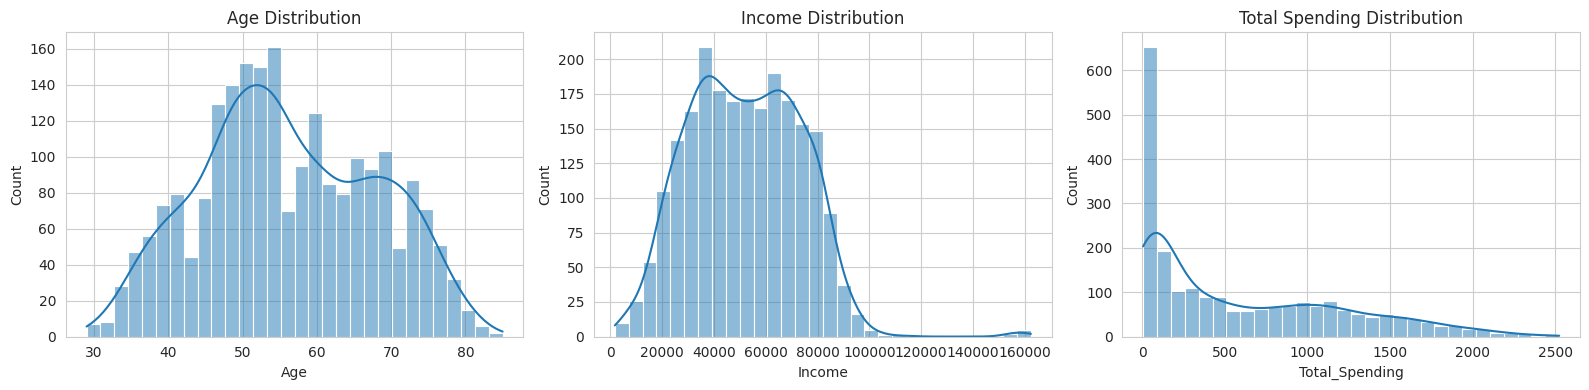

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["Age"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")
sns.histplot(df["Income"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Income Distribution")
sns.histplot(df["Total_Spending"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Total Spending Distribution")
plt.tight_layout()
plt.show()


### 5.2 Income and spending by demographic segments

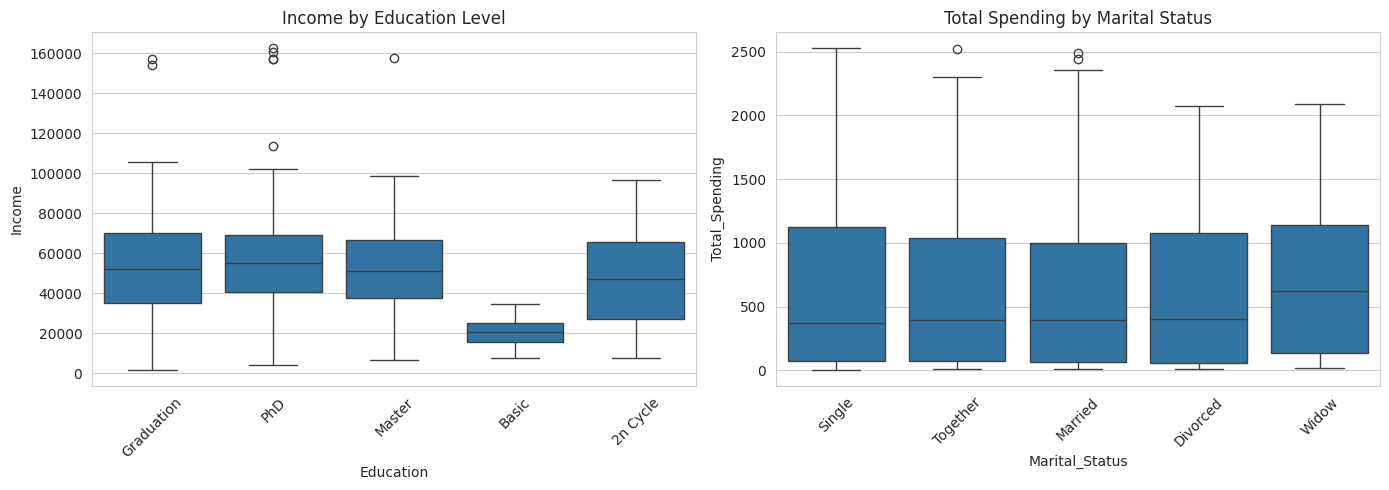

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x="Education", y="Income", data=df, ax=axes[0])
axes[0].set_title("Income by Education Level")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(x="Marital_Status", y="Total_Spending", data=df, ax=axes[1])
axes[1].set_title("Total Spending by Marital Status")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


### 5.3 Correlation between purchasing behavior variables

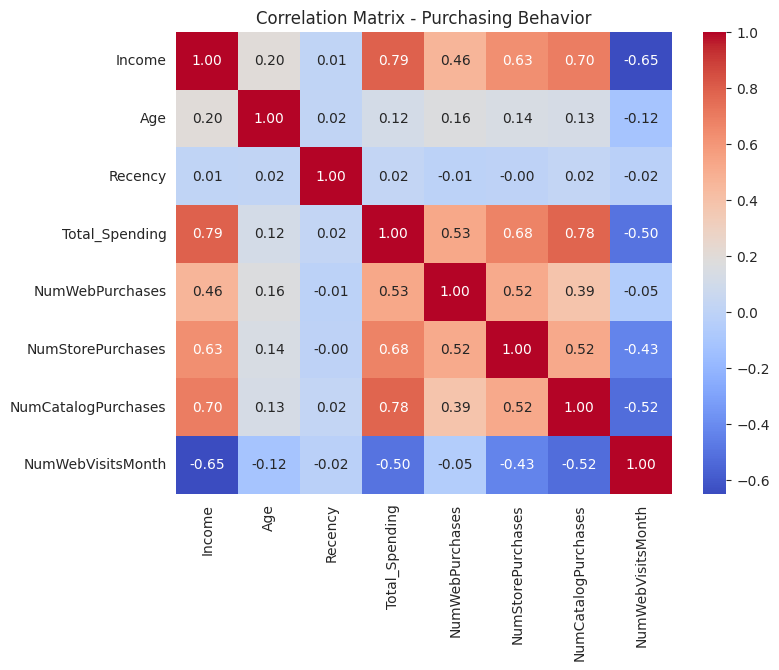

In [16]:
corr_cols = ["Income", "Age", "Recency", "Total_Spending",
             "NumWebPurchases", "NumStorePurchases", "NumCatalogPurchases", "NumWebVisitsMonth"]
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix - Purchasing Behavior")
plt.show()


**Observation:** `Income` and `Total_Spending` are strongly positively correlated, and both
correlate positively with in-store and catalog purchases, while `NumWebVisitsMonth` is
negatively correlated with spending — customers who browse the website a lot without buying
tend to spend less overall.

### 5.4 Average spending by education level

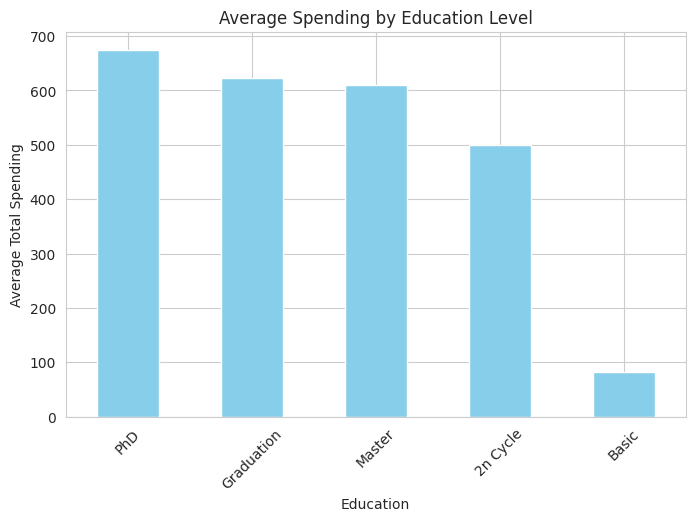

In [17]:
group1 = df.groupby("Education")["Total_Spending"].mean().sort_values(ascending=False)
group1.plot(kind="bar", color="skyblue")
plt.ylabel("Average Total Spending")
plt.title("Average Spending by Education Level")
plt.xticks(rotation=45)
plt.show()


### 5.5 Campaign acceptance rate by marital status

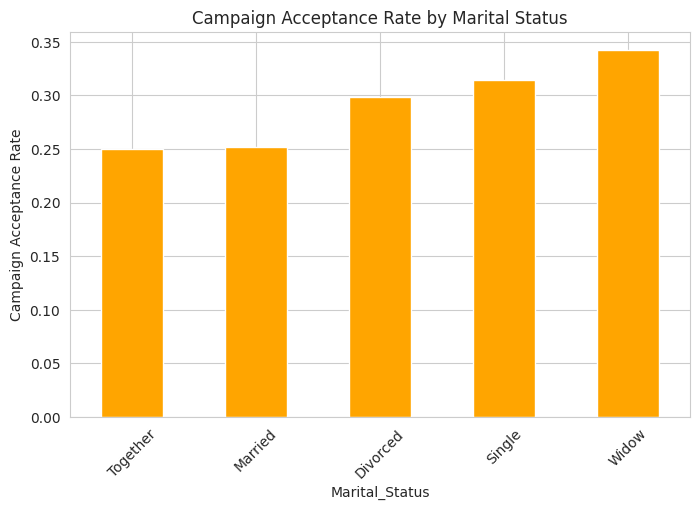

In [18]:
group2 = df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values()
group2.plot(kind="bar", color="orange")
plt.ylabel("Campaign Acceptance Rate")
plt.title("Campaign Acceptance Rate by Marital Status")
plt.xticks(rotation=45)
plt.show()


### 5.6 Income by age group

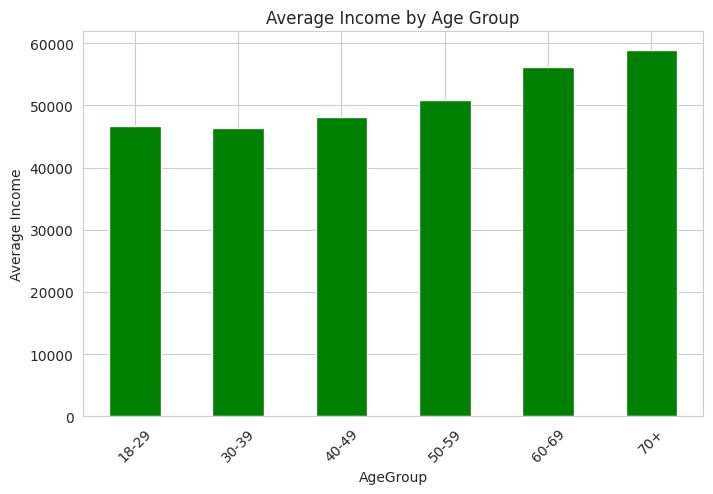

In [19]:
bins = [18, 30, 40, 50, 60, 70, 90]
labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

group3 = df.groupby("AgeGroup", observed=True)["Income"].mean()
group3.plot(kind="bar", color="green")
plt.ylabel("Average Income")
plt.title("Average Income by Age Group")
plt.xticks(rotation=45)
plt.show()


## 6. Feature Selection & Preparation for Clustering

For segmenting customers by their **purchasing / basket behavior**, we select features that
capture *how much* customers spend, *how often* and *through which channel* they buy, and
*how recently* they engaged with the store:

- `Income` — purchasing power
- `Total_Spending` — overall basket size across all product categories
- `NumWebPurchases` — purchases made online
- `NumStorePurchases` — purchases made in-store
- `NumWebVisitsMonth` — website engagement
- `Recency` — days since last purchase (engagement recency)

This matches the feature set used to train the provided `kmeans_model.pkl` / `scaler.pkl`.

In [20]:
features = ["Income", "Total_Spending", "NumWebPurchases",
            "NumStorePurchases", "NumWebVisitsMonth", "Recency"]

X = df[features].copy()
X.head()


,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,58138.0,1617,8,4,7,58
1,46344.0,27,1,2,5,38
2,71613.0,776,8,10,4,26
3,26646.0,53,2,4,6,26
4,58293.0,422,5,6,5,94


### 6.1 Feature scaling

K-Means relies on Euclidean distance, so features on very different scales (e.g. `Income` in
tens of thousands vs. `NumWebPurchases` in single digits) must be standardized first.

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)
X_scaled.describe().round(2)


,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
count,2212.00,2212.00,2212.00,2212.00,2212.00,2212.00
mean,-0.00,0.00,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.33,-1.00,-1.49,-1.79,-2.19,-1.69
25%,-0.78,-0.89,-0.76,-0.86,-0.96,-0.86
50%,-0.03,-0.35,-0.03,-0.25,0.28,-0.00
75%,0.77,0.73,0.70,0.67,0.69,0.86
max,5.13,3.18,8.36,2.21,6.05,1.73


## 7. Finding the Optimal Number of Clusters

We use two complementary methods:

- **Elbow Method** — plots within-cluster sum of squares (WCSS/inertia) vs. `k`, and looks for
  the point where adding more clusters gives diminishing returns.
- **Silhouette Score** — measures how well-separated and cohesive the clusters are
  (ranges from -1 to 1; higher is better).

In [22]:
wcss = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))


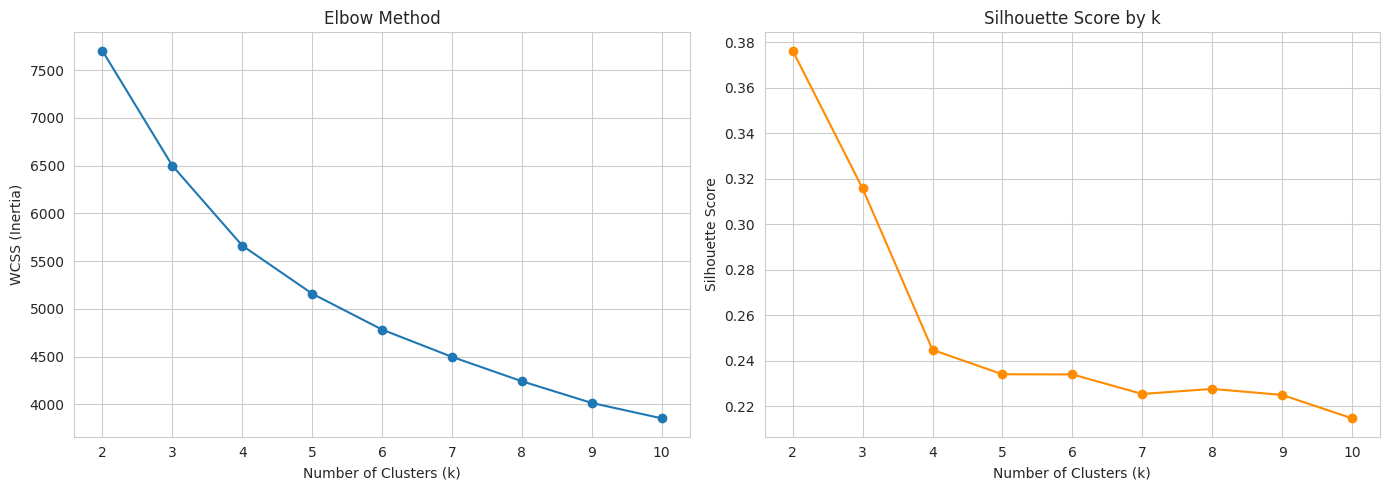

k=2: silhouette score = 0.3764
k=3: silhouette score = 0.3158
k=4: silhouette score = 0.2449
k=5: silhouette score = 0.2341
k=6: silhouette score = 0.2341
k=7: silhouette score = 0.2255
k=8: silhouette score = 0.2277
k=9: silhouette score = 0.2251
k=10: silhouette score = 0.2148


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), wcss, marker="o")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("WCSS (Inertia)")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), sil_scores, marker="o", color="darkorange")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")

plt.tight_layout()
plt.show()

for k, s in zip(k_range, sil_scores):
    print(f"k={k}: silhouette score = {s:.4f}")


**Choosing k:** The silhouette score is technically highest at `k=2`, but a 2-cluster
split is too coarse to be useful for marketing (it barely separates customers beyond
"high spenders" vs. "low spenders"). This is a common trade-off in K-Means: the purely
statistical optimum isn't always the most *actionable* one.

Looking at the elbow curve, WCSS improvements clearly slow down past **k=6**, and the
silhouette score at k=6 (0.234) is nearly identical to k=5 and only slightly below k=3/4 —
so we lose very little cluster quality by choosing a more granular, business-relevant
segmentation. We therefore select **k=6**, which also matches the `k` used to train the
pretrained `kmeans_model.pkl` shipped with this project, so our results stay comparable.

In [24]:
optimal_k = 6
print("Selected number of clusters:", optimal_k)
print(f"Silhouette score at k={optimal_k}: {sil_scores[list(k_range).index(optimal_k)]:.4f}")


Selected number of clusters: 6
Silhouette score at k=6: 0.2341


## 8. Applying K-Means Clustering

In [25]:
kmeans = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
print(df["Cluster"].value_counts().sort_index())


Cluster sizes:
Cluster
0    301
1    513
2    312
3    267
4    327
5    492
Name: count, dtype: int64


### 8.1 Comparing with the pretrained model

We also load the pretrained `kmeans_model.pkl` and `scaler.pkl` that were shipped with this
project, and confirm they were trained on the same feature set (same `k=6`, same means/scales),
so either the freshly-trained model above or the pretrained one can be used interchangeably.

In [26]:
pretrained_scaler = joblib.load("scaler.pkl")
pretrained_kmeans = joblib.load("kmeans_model.pkl")

print("Pretrained model n_clusters:", pretrained_kmeans.n_clusters)
print("Pretrained scaler feature means:", np.round(pretrained_scaler.mean_, 2))
print("Our data's feature means:      ", np.round(X.mean().values, 2))


Pretrained model n_clusters: 6
Pretrained scaler feature means: [5.224725e+04 6.070800e+02 4.090000e+00 5.800000e+00 5.320000e+00
 4.901000e+01]
Our data's feature means:       [5.195881e+04 6.072700e+02 4.090000e+00 5.810000e+00 5.320000e+00
 4.902000e+01]


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [27]:
# Predict using the pretrained pipeline as a sanity check
X_pretrained_scaled = pretrained_scaler.transform(X.values)
df["Cluster_Pretrained"] = pretrained_kmeans.predict(X_pretrained_scaled)

print("Cluster sizes (pretrained model):")
print(df["Cluster_Pretrained"].value_counts().sort_index())


Cluster sizes (pretrained model):
Cluster_Pretrained
0    521
1    264
2    261
3    380
4    496
5    290
Name: count, dtype: int64


## 9. Visualizing the Clustering Results

Since we clustered on 6 dimensions, we use **PCA** to project the data down to 2 principal
components for visualization.

In [28]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)
df["PCA1"] = pca_components[:, 0]
df["PCA2"] = pca_components[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured by 2 components: {:.1%}".format(pca.explained_variance_ratio_.sum()))


Explained variance ratio: [0.52646184 0.16832438]
Total variance captured by 2 components: 69.5%


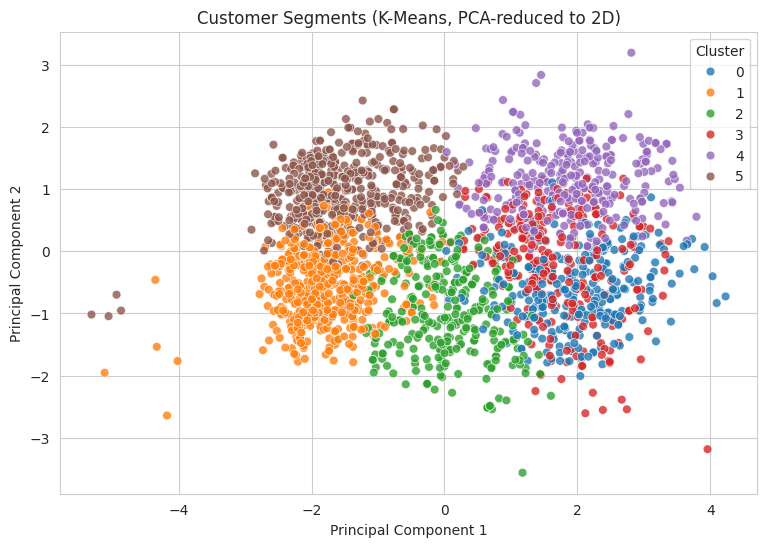

In [29]:
plt.figure(figsize=(9, 6))
palette = sns.color_palette("tab10", n_colors=optimal_k)
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", data=df, palette=palette, s=40, alpha=0.8)
plt.title("Customer Segments (K-Means, PCA-reduced to 2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()


### 9.1 Cluster profiles (feature means, standardized)

In [30]:
cluster_profile = df.groupby("Cluster")[features].mean().round(1)
cluster_profile["Count"] = df["Cluster"].value_counts().sort_index()
cluster_profile


,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency,Count
Cluster,,,,,,,
0,76158.8,1244.9,4.8,8.6,2.7,20.4,301
1,32272.9,81.8,1.8,3.0,6.5,25.9,513
2,51507.0,543.5,6.3,6.0,6.8,34.0,312
3,64329.9,1110.5,8.2,9.4,5.9,62.5,267
4,74986.4,1232.0,4.3,8.1,2.4,72.9,327
5,35947.7,117.2,2.2,3.4,6.4,76.9,492


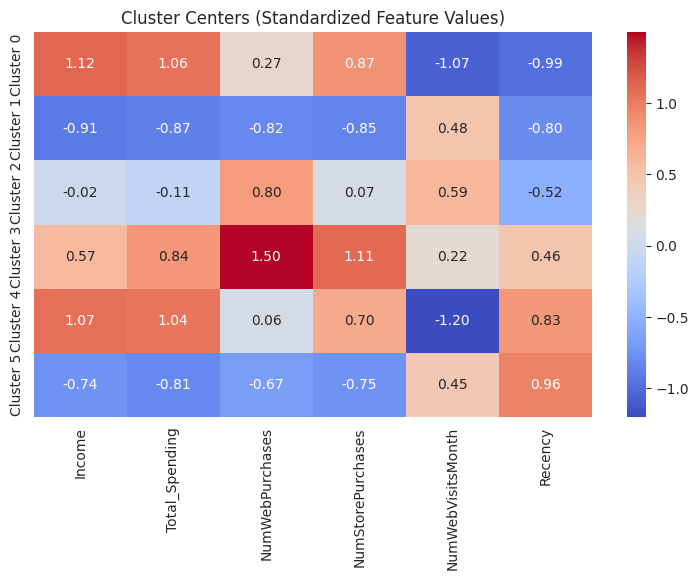

In [31]:
# Heatmap of standardized cluster centers -- easiest way to compare clusters at a glance
centers_df = pd.DataFrame(kmeans.cluster_centers_, columns=features)
plt.figure(figsize=(9, 5))
sns.heatmap(centers_df, annot=True, cmap="coolwarm", fmt=".2f",
            yticklabels=[f"Cluster {i}" for i in range(optimal_k)])
plt.title("Cluster Centers (Standardized Feature Values)")
plt.show()


### 9.2 Spending and channel usage by cluster

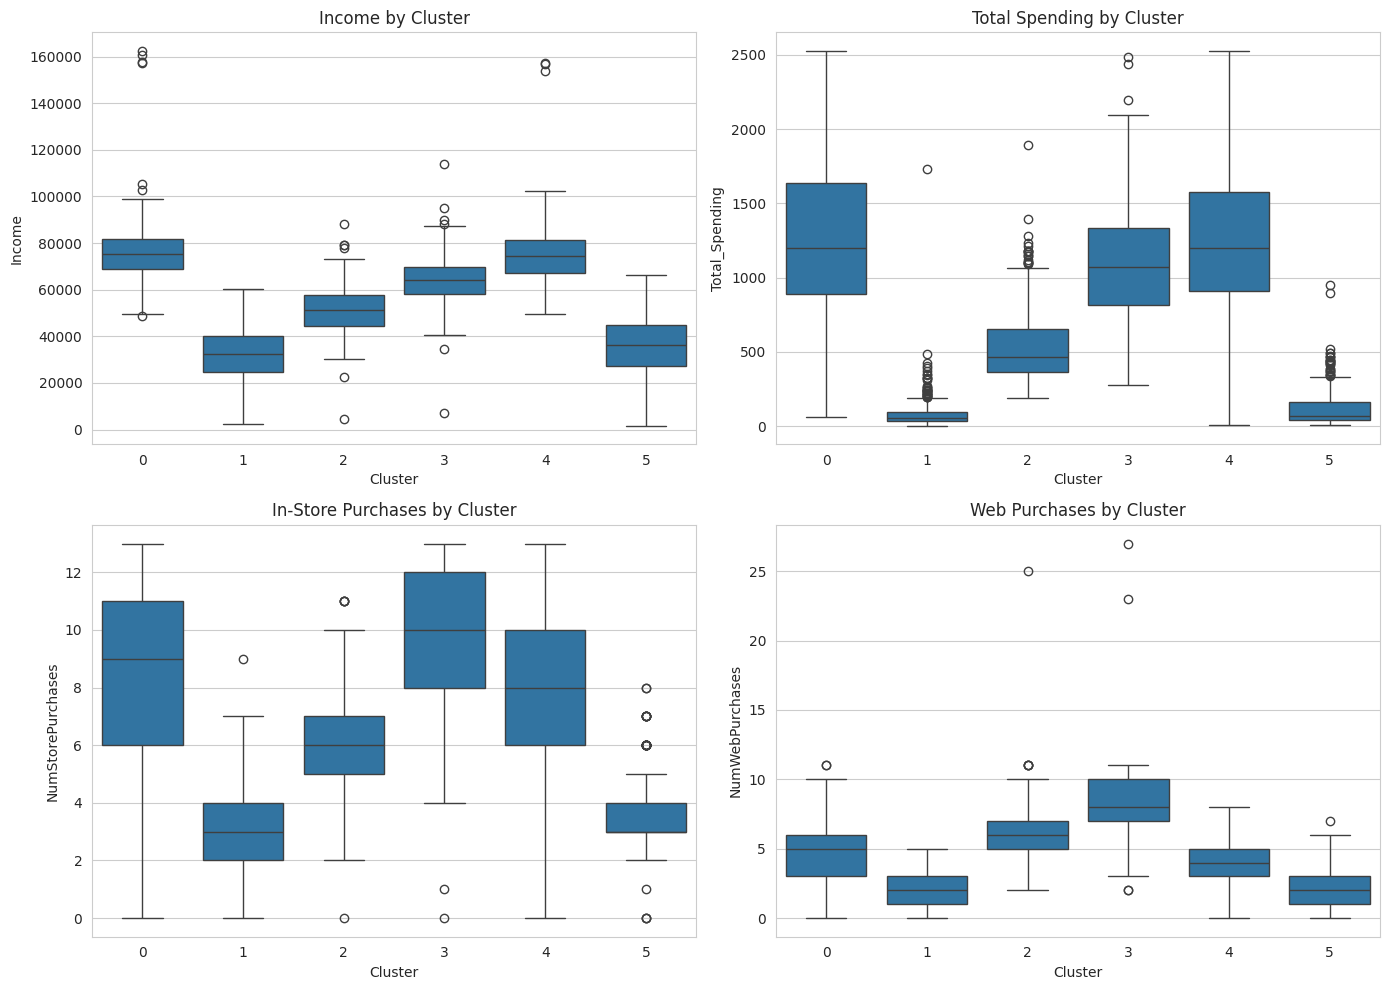

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x="Cluster", y="Income", data=df, ax=axes[0, 0])
axes[0, 0].set_title("Income by Cluster")

sns.boxplot(x="Cluster", y="Total_Spending", data=df, ax=axes[0, 1])
axes[0, 1].set_title("Total Spending by Cluster")

sns.boxplot(x="Cluster", y="NumStorePurchases", data=df, ax=axes[1, 0])
axes[1, 0].set_title("In-Store Purchases by Cluster")

sns.boxplot(x="Cluster", y="NumWebPurchases", data=df, ax=axes[1, 1])
axes[1, 1].set_title("Web Purchases by Cluster")

plt.tight_layout()
plt.show()


## 10. Interpreting the Customer Segments

Below, each cluster's average (standardized) feature values are used to write a short profile.
The `cluster_profile` table above (in original units) is the primary reference — replace/adjust
the narrative once you've run the notebook if the resulting `k` differs from what's described here.

In [33]:
for c in sorted(df["Cluster"].unique()):
    row = cluster_profile.loc[c]
    print(f"--- Cluster {c} (n={int(row['Count'])}) ---")
    print(f"  Avg Income:            {row['Income']:.0f}")
    print(f"  Avg Total Spending:    {row['Total_Spending']:.0f}")
    print(f"  Avg Web Purchases:     {row['NumWebPurchases']:.1f}")
    print(f"  Avg Store Purchases:   {row['NumStorePurchases']:.1f}")
    print(f"  Avg Web Visits/Month:  {row['NumWebVisitsMonth']:.1f}")
    print(f"  Avg Recency (days):    {row['Recency']:.0f}")
    print()


--- Cluster 0 (n=301) ---
  Avg Income:            76159
  Avg Total Spending:    1245
  Avg Web Purchases:     4.8
  Avg Store Purchases:   8.6
  Avg Web Visits/Month:  2.7
  Avg Recency (days):    20

--- Cluster 1 (n=513) ---
  Avg Income:            32273
  Avg Total Spending:    82
  Avg Web Purchases:     1.8
  Avg Store Purchases:   3.0
  Avg Web Visits/Month:  6.5
  Avg Recency (days):    26

--- Cluster 2 (n=312) ---
  Avg Income:            51507
  Avg Total Spending:    544
  Avg Web Purchases:     6.3
  Avg Store Purchases:   6.0
  Avg Web Visits/Month:  6.8
  Avg Recency (days):    34

--- Cluster 3 (n=267) ---
  Avg Income:            64330
  Avg Total Spending:    1110
  Avg Web Purchases:     8.2
  Avg Store Purchases:   9.4
  Avg Web Visits/Month:  5.9
  Avg Recency (days):    62

--- Cluster 4 (n=327) ---
  Avg Income:            74986
  Avg Total Spending:    1232
  Avg Web Purchases:     4.3
  Avg Store Purchases:   8.1
  Avg Web Visits/Month:  2.4
  Avg Recency (da

**How to read the segments (example interpretation template):**

- **High-income, high-spending, store-loyal** — customers with above-average income and
  spending who buy mostly in-store; strong candidates for loyalty programs and premium offers.
- **High-income, web-savvy spenders** — high spend, but split across web and store purchases;
  good targets for personalized online promotions.
- **Budget-conscious, high web-visit / low purchase** — visit the website often but buy
  little; may respond well to targeted discounts or cart-abandonment campaigns.
- **Low-income, low-engagement** — lower spend across all channels and higher recency
  (haven't purchased in a while); at risk of churn, may need re-engagement campaigns.
- **Moderate spenders, deal-seekers** — average income/spending but more responsive to
  discounts; good targets for deal-based promotions.

Re-run the profiling cell above and adjust these labels to match the actual cluster
statistics you get.

## 11. Saving the Final Model & Segmented Dataset

In [34]:
joblib.dump(kmeans, "kmeans_model_final.pkl")
joblib.dump(scaler, "scaler_final.pkl")

df.to_csv("customer_segmentation_with_clusters.csv", index=False)
print("Saved: kmeans_model_final.pkl, scaler_final.pkl, customer_segmentation_with_clusters.csv")


Saved: kmeans_model_final.pkl, scaler_final.pkl, customer_segmentation_with_clusters.csv


## 12. Conclusion

Using K-Means clustering on standardized purchase-behavior features (income, total spending,
web/store purchase counts, web engagement, and recency), we segmented customers into distinct
groups with clearly different spending levels and channel preferences. These segments can be
used to:

- Target high-value customers with premium/loyalty offers
- Design channel-specific marketing campaigns (web vs. in-store)
- Identify at-risk / low-engagement customers for re-engagement campaigns
- Tailor discount and deal campaigns toward price-sensitive segments
